# Modelo de Clasificación - Detección de Anomalías en Consumo Eléctrico
<br>

**Objetivo:** Desarrollar un modelo de clasificación para detectar anomalías en el consumo eléctrico utilizando **SVM y XGBoost** con optimización de hiperparámetros mediante **Grid Search**.

**Dataset:** Datos ya limpios y preprocesados

**Variable Objetivo:** `Abnormal_Usage` (0 = Normal, 1 = Anómalo)

**Tipo de problema:** Clasificación binaria

**Algoritmos a utilizar:**
- Support Vector Machine (SVM)
- XGBoost (Extreme Gradient Boosting)



## 1. Importar las librerías necesarias

In [ ]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Preprocesamiento
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score, roc_auc_score, 
                             roc_curve, precision_recall_curve, average_precision_score)

# Modelos
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Para manejo de desbalance (si es necesario)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Cargar los datos limpios

In [12]:
# Cargar el dataset limpio
# NOTA: Asegúrate de que la ruta sea correcta según dónde guardaste tu archivo limpio
df = pd.read_csv('../data/datos_limpios_anomalias.csv')

print("Datos cargados:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas:")
print(df.columns.tolist())
print(f"\nPrimeras 5 filas:")
df.head()

Datos cargados:
Dimensiones: (10800, 19)

Columnas:
['Num_Occupants', 'House_Area (sqft)', 'Appliance_Score', 'Connected_Load(kw)', 'Temperature_C', 'Humidity (%)', 'Expected_Energy(kwh)', 'Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Cluster_Avg_Energy(kwh)', 'Abnormal_Usage', 'Month', 'Year', 'Region_Code_IN_KL_ALP', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_TVM', 'Dwelling_Type_Apartment', 'Dwelling_Type_Independent House', 'Dwelling_Type_Villa']

Primeras 5 filas:


,Num_Occupants,House_Area (sqft),Appliance_Score,Connected_Load(kw),Temperature_C,Humidity (%),Expected_Energy(kwh),Actual_Energy(kwh),Usage_Deviation(%),Cluster_Avg_Energy(kwh),Abnormal_Usage,Month,Year,Region_Code_IN_KL_ALP,Region_Code_IN_KL_ERN,Region_Code_IN_KL_TVM,Dwelling_Type_Apartment,Dwelling_Type_Independent House,Dwelling_Type_Villa
0,2,1.108194,6,1.225870,-0.108795,1.633974,-1.036012,0.319133,1.460891,0.228746,1,1,2023,0,0,1,0,1,0
1,3,0.878010,9,1.723842,-1.033049,-1.389365,-0.395372,-0.516777,-0.371645,2.110315,0,1,2023,1,0,0,0,1,0
2,3,1.060180,16,0.100582,0.489842,-1.574734,0.304458,-0.593185,-0.934931,0.969364,0,1,2023,0,0,1,1,0,0
3,1,1.572799,18,0.061779,-2.205274,-0.545198,-1.074312,0.581787,1.912708,-0.331721,1,1,2023,0,1,0,1,0,0
4,4,1.010754,10,-1.503276,0.239366,1.088311,-0.788809,-1.059273,-0.823463,-0.692021,0,1,2023,0,1,0,0,1,0


## 3. Verificación de los datos preprocesados

In [13]:
# Información del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10800 entries, 0 to 10799
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Num_Occupants                    10800 non-null  int64  
 1   House_Area (sqft)                10800 non-null  float64
 2   Appliance_Score                  10800 non-null  int64  
 3   Connected_Load(kw)               10800 non-null  float64
 4   Temperature_C                    10800 non-null  float64
 5   Humidity (%)                     10800 non-null  float64
 6   Expected_Energy(kwh)             10800 non-null  float64
 7   Actual_Energy(kwh)               10800 non-null  float64
 8   Usage_Deviation(%)               10800 non-null  float64
 9   Cluster_Avg_Energy(kwh)          10800 non-null  float64
 10  Abnormal_Usage                   10800 non-null  int64  
 11  Month                            10800 non-null  int64  
 12  Year

In [14]:
# Verificar valores faltantes
print("Valores faltantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No hay valores faltantes")
else:
    print(missing[missing > 0])

Valores faltantes:
No hay valores faltantes


Distribución de la variable objetivo (Abnormal_Usage):
Abnormal_Usage
0    6061
1    4739
Name: count, dtype: int64

Porcentajes:
Abnormal_Usage
0    56.12037
1    43.87963
Name: proportion, dtype: float64


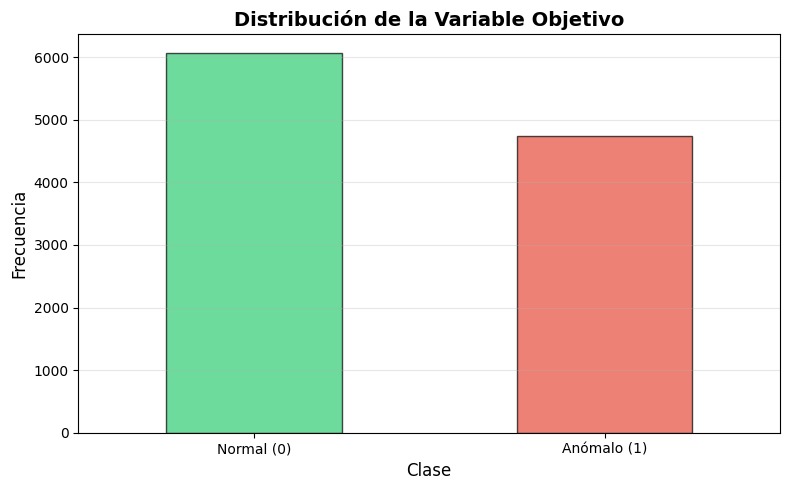

In [5]:
# Distribución de la variable objetivo
print("Distribución de la variable objetivo (Abnormal_Usage):")
print(df['Abnormal_Usage'].value_counts())
print(f"\nPorcentajes:")
print(df['Abnormal_Usage'].value_counts(normalize=True) * 100)

# Visualizar
plt.figure(figsize=(8, 5))
df['Abnormal_Usage'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
plt.title('Distribución de la Variable Objetivo', fontsize=14, fontweight='bold')
plt.xlabel('Clase', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks([0, 1], ['Normal (0)', 'Anómalo (1)'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Preparación de los datos para modelado

### 4.1 Separar features (X) y variable objetivo (y)

In [6]:
# Separar features y target
X = df.drop('Abnormal_Usage', axis=1)
y = df['Abnormal_Usage']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")
print(f"\nFeatures utilizadas: {X.columns.tolist()}")

Shape de X (features): (10800, 18)
Shape de y (target): (10800,)

Features utilizadas: ['Num_Occupants', 'House_Area (sqft)', 'Appliance_Score', 'Connected_Load(kw)', 'Temperature_C', 'Humidity (%)', 'Expected_Energy(kwh)', 'Actual_Energy(kwh)', 'Usage_Deviation(%)', 'Cluster_Avg_Energy(kwh)', 'Month', 'Year', 'Region_Code_IN_KL_ALP', 'Region_Code_IN_KL_ERN', 'Region_Code_IN_KL_TVM', 'Dwelling_Type_Apartment', 'Dwelling_Type_Independent House', 'Dwelling_Type_Villa']


### 4.2 División en conjuntos de entrenamiento y prueba

In [15]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y  # Mantener la proporción de clases
)

print("División de datos:")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras ({(len(X_train)/len(X))*100:.1f}%)")
print(f"  - Prueba: {X_test.shape[0]} muestras ({(len(X_test)/len(X))*100:.1f}%)")

print(f"\nDistribución de clases en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución de clases en prueba:")
print(y_test.value_counts())

División de datos:
  - Entrenamiento: 8640 muestras (80.0%)
  - Prueba: 2160 muestras (20.0%)

Distribución de clases en entrenamiento:
Abnormal_Usage
0    4849
1    3791
Name: count, dtype: int64

Distribución de clases en prueba:
Abnormal_Usage
0    1212
1     948
Name: count, dtype: int64


### 4.3 Escalado de features

**Importante:** SVM es sensible a la escala de las variables, por lo que es fundamental escalar los datos.

In [16]:
# Inicializar el escalador
scaler = StandardScaler()

# Ajustar con train y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("Datos escalados correctamente")
print(f"\nEstadísticas después del escalado (train):")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

Datos escalados correctamente

Estadísticas después del escalado (train):
      Num_Occupants  House_Area (sqft)  Appliance_Score  Connected_Load(kw)  \
mean            0.0                0.0              0.0                -0.0   
std             1.0                1.0              1.0                 1.0   

      Temperature_C  Humidity (%)  Expected_Energy(kwh)  Actual_Energy(kwh)  \
mean            0.0          -0.0                  -0.0                 0.0   
std             1.0           1.0                   1.0                 1.0   

      Usage_Deviation(%)  Cluster_Avg_Energy(kwh)  Month  Year  \
mean                -0.0                     -0.0    0.0   0.0   
std                  1.0                      1.0    0.0   0.0   

      Region_Code_IN_KL_ALP  Region_Code_IN_KL_ERN  Region_Code_IN_KL_TVM  \
mean                   -0.0                   -0.0                   -0.0   
std                     1.0                    1.0                    1.0   

      Dwelling_Type

## 5. Modelo 1: Support Vector Machine (SVM)

### 5.1 Modelo base (sin optimización)

In [18]:
# Entrenar SVM con parámetros por defecto
print("Entrenando SVM con parámetros por defecto...")
svm_base = SVC(random_state=RANDOM_STATE, probability=True)
svm_base.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm_base = svm_base.predict(X_test_scaled)
y_pred_proba_svm_base = svm_base.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("RESULTADOS SVM BASE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_base, target_names=['Normal', 'Anómalo']))

Entrenando SVM con parámetros por defecto...
RESULTADOS SVM BASE
Accuracy: 0.8931
Precision: 0.9786
Recall: 0.7732
F1-Score: 0.8639
ROC-AUC: 0.9420

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.85      0.99      0.91      1212
     Anómalo       0.98      0.77      0.86       948

    accuracy                           0.89      2160
   macro avg       0.91      0.88      0.89      2160
weighted avg       0.91      0.89      0.89      2160



### 5.2 Optimización con Grid Search

Vamos a optimizar los hiperparámetros más importantes de SVM:
- `C`: Parámetro de regularización
- `kernel`: Tipo de kernel (linear, rbf, poly)
- `gamma`: Coeficiente del kernel

**ESTRATEGIA OPTIMIZADA:** Para datasets grandes (10,000+ registros), usaremos una muestra estratificada para la búsqueda de hiperparámetros, lo cual reduce significativamente el tiempo de cómputo. El modelo final se entrenará con todos los datos.

In [27]:
print("Preparando búsqueda de hiperparámetros...")

# Tomar 30% de los datos para búsqueda (suficiente para encontrar buenos parámetros)
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, y_train, 
    train_size=0.3,  
    random_state=RANDOM_STATE,
    stratify=y_train  # Mantiene la proporción de clases
)

print(f"Tamaño del dataset de entrenamiento completo: {len(X_train_scaled):,}")
print(f"Tamaño de la muestra para Grid Search: {len(X_train_sample):,}")

Preparando búsqueda de hiperparámetros...
Tamaño del dataset de entrenamiento completo: 8,640
Tamaño de la muestra para Grid Search: 2,592


In [28]:
param_grid_svm = {
    'C': [0.1, 1, 10],              # 3 valores
    'kernel': ['rbf'],               # Solo RBF (el más usado y efectivo)
    'gamma': ['scale', 0.1, 1]       # 3 valores
}

print(f"\nGrilla de hiperparámetros para SVM:")
print(param_grid_svm)
total_combinaciones = len(param_grid_svm['C']) * len(param_grid_svm['kernel']) * len(param_grid_svm['gamma'])
print(f"Total de combinaciones: {total_combinaciones}")
print(f"Con 3-fold CV: {total_combinaciones * 3} entrenamientos")




Grilla de hiperparámetros para SVM:
{'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.1, 1]}
Total de combinaciones: 9
Con 3-fold CV: 27 entrenamientos


In [29]:
print(f"\nIniciando Grid Search para SVM...")
print(f"Tiempo estimado: 5-10 minutos\n")

# Usar 3-fold en lugar de 5-fold para mayor velocidad
cv_strategy_quick = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE, probability=True),
    param_grid=param_grid_svm,
    cv=cv_strategy_quick,
    scoring='f1',  # Optimizar F1-score (balancea precision y recall)
    n_jobs=-1,     # Usar todos los cores disponibles
    verbose=2
)

# Entrenar con la MUESTRA
grid_search_svm.fit(X_train_sample, y_train_sample)

print("\nGrid Search completado")


Iniciando Grid Search para SVM...
Tiempo estimado: 5-10 minutos

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Grid Search completado


In [30]:
print("MEJORES HIPERPARÁMETROS SVM")
print(f"Mejores parámetros: {grid_search_svm.best_params_}")
print(f"Mejor F1-score (validación cruzada): {grid_search_svm.best_score_:.4f}")


MEJORES HIPERPARÁMETROS SVM
Mejores parámetros: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Mejor F1-score (validación cruzada): 0.8682


In [31]:

print("\nEntrenando modelo final con dataset completo...")

svm_best = SVC(
    C=grid_search_svm.best_params_['C'],
    kernel=grid_search_svm.best_params_['kernel'],
    gamma=grid_search_svm.best_params_['gamma'],
    random_state=RANDOM_STATE,
    probability=True
)

# Entrenar con el dataset COMPLETO (no la muestra)
svm_best.fit(X_train_scaled, y_train)

print("Modelo final SVM entrenado con todos los datos de entrenamiento")


Entrenando modelo final con dataset completo...
Modelo final SVM entrenado con todos los datos de entrenamiento


In [44]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_svm_best = svm_best.predict(X_test_scaled)
y_pred_proba_svm_best = svm_best.predict_proba(X_test_scaled)[:, 1]

print("RESULTADOS SVM OPTIMIZADO (TEST SET)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_svm_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_svm_best, target_names=['Normal', 'Anómalo']))

RESULTADOS SVM OPTIMIZADO (TEST SET)
Accuracy: 0.9255
Precision: 0.9816
Recall: 0.8460
F1-Score: 0.9088
ROC-AUC: 0.9670

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.89      0.99      0.94      1212
     Anómalo       0.98      0.85      0.91       948

    accuracy                           0.93      2160
   macro avg       0.94      0.92      0.92      2160
weighted avg       0.93      0.93      0.92      2160



### 5.3 Matriz de confusión SVM

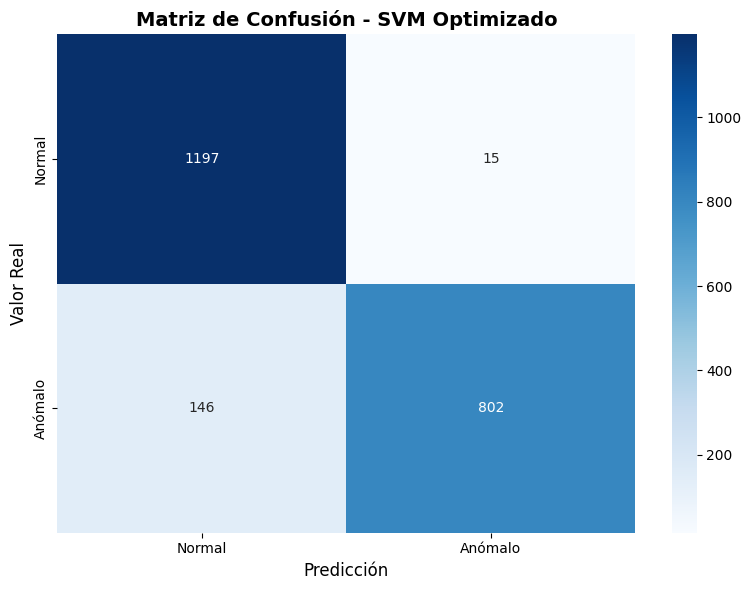


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1197 (Normal predicho correctamente)
  - Falsos Positivos (FP): 15 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 146 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 802 (Anómalo predicho correctamente)


In [45]:
# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - SVM Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_svm.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

## 6. Modelo 2: XGBoost

### 6.1 Modelo base (sin optimización)

In [34]:
# Entrenar XGBoost con parámetros por defecto
print("Entrenando XGBoost con parámetros por defecto...")
xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss')
xgb_base.fit(X_train, y_train)  # XGBoost no requiere escalado

# Predicciones
y_pred_xgb_base = xgb_base.predict(X_test)
y_pred_proba_xgb_base = xgb_base.predict_proba(X_test)[:, 1]

# Métricas
print("RESULTADOS XGBOOST BASE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_base):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_base):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_base):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_base, target_names=['Normal', 'Anómalo']))

Entrenando XGBoost con parámetros por defecto...
RESULTADOS XGBOOST BASE
Accuracy: 0.9898
Precision: 0.9894
Recall: 0.9873
F1-Score: 0.9884
ROC-AUC: 0.9983

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 6.2 Optimización con Grid Search

Hiperparámetros importantes de XGBoost:
- `n_estimators`: Número de árboles
- `max_depth`: Profundidad máxima de los árboles
- `learning_rate`: Tasa de aprendizaje
- `subsample`: Fracción de muestras para cada árbol
- `colsample_bytree`: Fracción de features para cada árbol

In [35]:
# Definir la grilla de hiperparámetros
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

print("Grilla de hiperparámetros para XGBoost:")
print(param_grid_xgb)
print(f"\nTotal de combinaciones: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate']) * len(param_grid_xgb['subsample']) * len(param_grid_xgb['colsample_bytree'])}")

Grilla de hiperparámetros para XGBoost:
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7, 9], 'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0]}

Total de combinaciones: 324


In [36]:
# Configurar Grid Search
print("Iniciando Grid Search para XGBoost...")
print("(Esto puede tomar varios minutos)\n")

grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Usar la misma muestra que con SVM
X_train_xgb_sample, _, y_train_xgb_sample, _ = train_test_split(
    X_train, y_train, 
    train_size=0.3,  
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Grid Search con muestra
grid_search_xgb.fit(X_train_xgb_sample, y_train_xgb_sample)

print("\nGrid Search completado")

Iniciando Grid Search para XGBoost...
(Esto puede tomar varios minutos)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Grid Search completado


In [38]:
# Mejores hiperparámetros encontrados
print("MEJORES HIPERPARÁMETROS XGBOOST")
print(f"Mejores parámetros: {grid_search_xgb.best_params_}")
print(f"Mejor F1-score (validación cruzada): {grid_search_xgb.best_score_:.4f}")

# Modelo final con todos los datos
xgb_best = XGBClassifier(
    n_estimators=grid_search_xgb.best_params_['n_estimators'],
    max_depth=grid_search_xgb.best_params_['max_depth'],
    learning_rate=grid_search_xgb.best_params_['learning_rate'],
    subsample=grid_search_xgb.best_params_['subsample'],
    colsample_bytree=grid_search_xgb.best_params_['colsample_bytree'],
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb_best.fit(X_train, y_train)

MEJORES HIPERPARÁMETROS XGBOOST
Mejores parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.3, 'max_depth': 9, 'n_estimators': 100, 'subsample': 0.8}
Mejor F1-score (validación cruzada): 0.9886


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [40]:
# Evaluar el mejor modelo en el conjunto de prueba
y_pred_xgb_best = xgb_best.predict(X_test)
y_pred_proba_xgb_best = xgb_best.predict_proba(X_test)[:, 1]

print("RESULTADOS XGBOOST OPTIMIZADO (TEST SET)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_best):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb_best):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb_best):.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_xgb_best, target_names=['Normal', 'Anómalo']))

RESULTADOS XGBOOST OPTIMIZADO (TEST SET)
Accuracy: 0.9907
Precision: 0.9884
Recall: 0.9905
F1-Score: 0.9895
ROC-AUC: 0.9990

Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1212
     Anómalo       0.99      0.99      0.99       948

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160



### 6.3 Matriz de confusión XGBoost

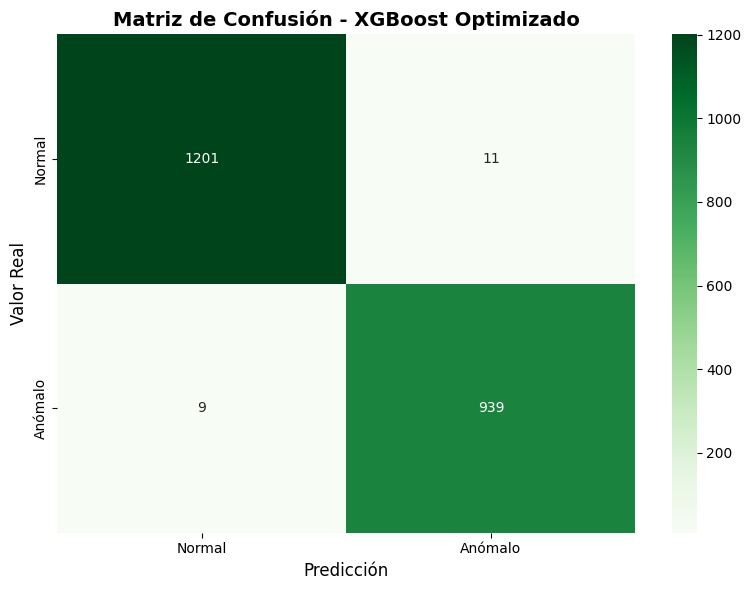


Interpretación de la matriz de confusión:
  - Verdaderos Negativos (TN): 1201 (Normal predicho correctamente)
  - Falsos Positivos (FP): 11 (Normal predicho como Anómalo)
  - Falsos Negativos (FN): 9 (Anómalo predicho como Normal)
  - Verdaderos Positivos (TP): 939 (Anómalo predicho correctamente)


In [41]:
# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Normal', 'Anómalo'],
            yticklabels=['Normal', 'Anómalo'])
plt.title('Matriz de Confusión - XGBoost Optimizado', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm_xgb.ravel()
print(f"\nInterpretación de la matriz de confusión:")
print(f"  - Verdaderos Negativos (TN): {tn} (Normal predicho correctamente)")
print(f"  - Falsos Positivos (FP): {fp} (Normal predicho como Anómalo)")
print(f"  - Falsos Negativos (FN): {fn} (Anómalo predicho como Normal)")
print(f"  - Verdaderos Positivos (TP): {tp} (Anómalo predicho correctamente)")

### 6.4 Importancia de features (XGBoost)

Importancia de features (XGBoost):
                            feature  importance
8                Usage_Deviation(%)    0.616042
7                Actual_Energy(kwh)    0.264352
9           Cluster_Avg_Energy(kwh)    0.058910
6              Expected_Energy(kwh)    0.010041
13            Region_Code_IN_KL_ERN    0.007537
4                     Temperature_C    0.005901
3                Connected_Load(kw)    0.005625
0                     Num_Occupants    0.005271
12            Region_Code_IN_KL_ALP    0.004818
15          Dwelling_Type_Apartment    0.004727
2                   Appliance_Score    0.004184
5                      Humidity (%)    0.004164
1                 House_Area (sqft)    0.003571
16  Dwelling_Type_Independent House    0.003301
14            Region_Code_IN_KL_TVM    0.001556
11                             Year    0.000000
10                            Month    0.000000
17              Dwelling_Type_Villa    0.000000


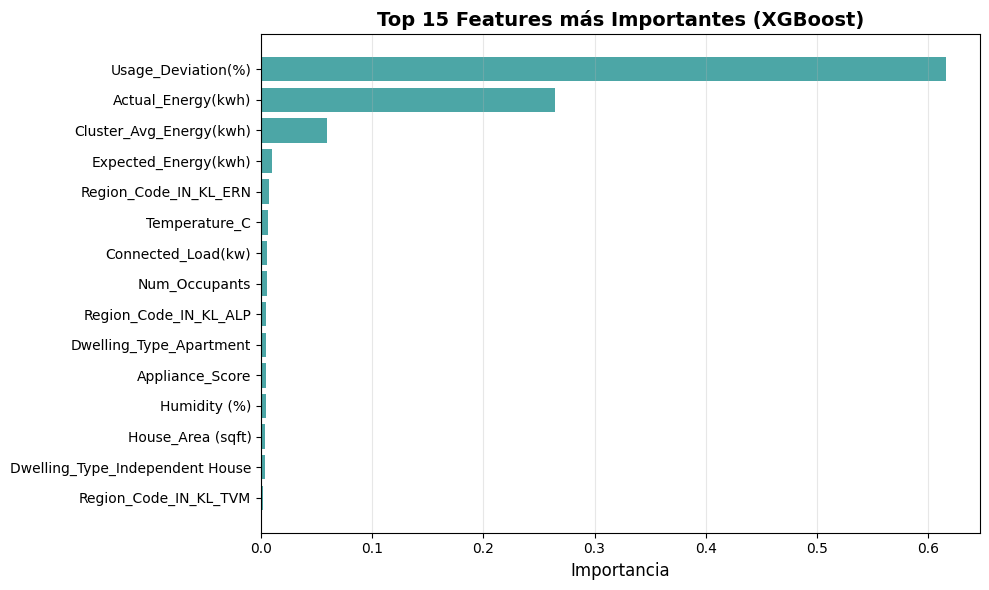

In [42]:
# Obtener importancia de features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("Importancia de features (XGBoost):")
print(feature_importance)

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15], color='teal', alpha=0.7)
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 15 Features más Importantes (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Comparación de Modelos

In [ ]:
# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': ['SVM Base', 'SVM Optimizado', 'XGBoost Base', 'XGBoost Optimizado'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm_base),
        accuracy_score(y_test, y_pred_svm_best),
        accuracy_score(y_test, y_pred_xgb_base),
        accuracy_score(y_test, y_pred_xgb_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm_base),
        precision_score(y_test, y_pred_svm_best),
        precision_score(y_test, y_pred_xgb_base),
        precision_score(y_test, y_pred_xgb_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm_base),
        recall_score(y_test, y_pred_svm_best),
        recall_score(y_test, y_pred_xgb_base),
        recall_score(y_test, y_pred_xgb_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_svm_base),
        f1_score(y_test, y_pred_svm_best),
        f1_score(y_test, y_pred_xgb_base),
        f1_score(y_test, y_pred_xgb_best)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_proba_svm_base),
        roc_auc_score(y_test, y_pred_proba_svm_best),
        roc_auc_score(y_test, y_pred_proba_xgb_base),
        roc_auc_score(y_test, y_pred_proba_xgb_best)
    ]
})

print("="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)
print(comparison_df.round(4))

# Encontrar el mejor modelo
best_model_idx = comparison_df['F1-Score'].idxmax()
print(f"\n🏆 Mejor modelo: {comparison_df.loc[best_model_idx, 'Modelo']}")
print(f"   F1-Score: {comparison_df.loc[best_model_idx, 'F1-Score']:.4f}")

In [ ]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, (idx, row) in enumerate(comparison_df.iterrows()):
    axes[0].bar(x + i*width, row[metrics].values, width, label=row['Modelo'], alpha=0.8)

axes[0].set_xlabel('Métricas', fontsize=12)
axes[0].set_ylabel('Valor', fontsize=12)
axes[0].set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Heatmap
sns.heatmap(comparison_df[metrics].T, annot=True, fmt='.3f', cmap='YlGnBu', 
            cbar_kws={'label': 'Score'}, ax=axes[1],
            xticklabels=comparison_df['Modelo'])
axes[1].set_title('Heatmap de Métricas', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Métrica', fontsize=12)

plt.tight_layout()
plt.show()

## 8. Curvas ROC

In [ ]:
# Calcular curvas ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm_best)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb_best)

# Graficar
plt.figure(figsize=(10, 8))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_score(y_test, y_pred_proba_svm_best):.3f})', 
         linewidth=2, color='blue')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb_best):.3f})', 
         linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Curvas Precision-Recall

In [ ]:
# Calcular curvas Precision-Recall
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_pred_proba_svm_best)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb_best)

# Calcular Average Precision
ap_svm = average_precision_score(y_test, y_pred_proba_svm_best)
ap_xgb = average_precision_score(y_test, y_pred_proba_xgb_best)

# Graficar
plt.figure(figsize=(10, 8))
plt.plot(recall_svm, precision_svm, label=f'SVM (AP = {ap_svm:.3f})', 
         linewidth=2, color='blue')
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP = {ap_xgb:.3f})', 
         linewidth=2, color='green')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curvas Precision-Recall - Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Análisis de Errores

In [ ]:
# Usar el mejor modelo (supongamos que es XGBoost)
# Identificar predicciones incorrectas
errors_xgb = X_test.copy()
errors_xgb['Real'] = y_test
errors_xgb['Predicho'] = y_pred_xgb_best
errors_xgb['Correcto'] = errors_xgb['Real'] == errors_xgb['Predicho']

# Filtrar solo errores
errores = errors_xgb[errors_xgb['Correcto'] == False]

print(f"Total de errores: {len(errores)} de {len(X_test)} ({(len(errores)/len(X_test))*100:.2f}%)")
print(f"\nDistribución de errores:")
print(errores.groupby(['Real', 'Predicho']).size())

if len(errores) > 0:
    print(f"\nPrimeros 10 casos mal clasificados:")
    print(errores[['Real', 'Predicho']].head(10))

## 11. Guardar los modelos

In [ ]:
import pickle

# Guardar el mejor modelo SVM
with open('modelo_svm_optimizado.pkl', 'wb') as f:
    pickle.dump(svm_best, f)
print("✓ Modelo SVM guardado: modelo_svm_optimizado.pkl")

# Guardar el mejor modelo XGBoost
with open('modelo_xgboost_optimizado.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)
print("✓ Modelo XGBoost guardado: modelo_xgboost_optimizado.pkl")

# Guardar el scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ Scaler guardado: scaler.pkl")

print("\n✓ Todos los modelos han sido guardados exitosamente")

## 12. Resumen Final y Conclusiones

In [ ]:
print("="*80)
print("RESUMEN FINAL DEL PROYECTO")
print("="*80)

print(f"\n1. DATOS:")
print(f"   - Total de muestras: {len(df):,}")
print(f"   - Features utilizadas: {len(X.columns)}")
print(f"   - Train/Test split: {len(X_train)}/{len(X_test)}")

print(f"\n2. MODELOS ENTRENADOS:")
print(f"   - SVM con Grid Search")
print(f"   - XGBoost con Grid Search")

print(f"\n3. MEJOR MODELO:")
best_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Modelo']
print(f"   - {best_model_name}")
print(f"   - Accuracy: {comparison_df.loc[best_idx, 'Accuracy']:.4f}")
print(f"   - Precision: {comparison_df.loc[best_idx, 'Precision']:.4f}")
print(f"   - Recall: {comparison_df.loc[best_idx, 'Recall']:.4f}")
print(f"   - F1-Score: {comparison_df.loc[best_idx, 'F1-Score']:.4f}")
print(f"   - ROC-AUC: {comparison_df.loc[best_idx, 'ROC-AUC']:.4f}")

print(f"\n4. ARCHIVOS GENERADOS:")
print(f"   - modelo_svm_optimizado.pkl")
print(f"   - modelo_xgboost_optimizado.pkl")
print(f"   - scaler.pkl")

print(f"\n5. PRÓXIMOS PASOS SUGERIDOS:")
print(f"   - Probar técnicas de balanceo (SMOTE, undersampling)")
print(f"   - Explorar ensemble methods")
print(f"   - Validar con datos nuevos")
print(f"   - Deployment del modelo")

print("\n" + "="*80)
print("¡Proyecto completado exitosamente!")
print("="*80)



## 📝 Notas Finales

### Interpretación de Métricas:

- **Accuracy:** Porcentaje total de predicciones correctas
- **Precision:** De todos los casos que predijimos como anómalos, ¿cuántos realmente lo son?
- **Recall (Sensibilidad):** De todos los casos realmente anómalos, ¿cuántos detectamos?
- **F1-Score:** Balance entre Precision y Recall (útil cuando las clases están desbalanceadas)
- **ROC-AUC:** Capacidad del modelo para distinguir entre clases

### ¿Qué métrica priorizar?

En detección de anomalías:
- Si es crítico **NO perder anomalías** (ej: fraude, fallas): Priorizar **Recall**
- Si es costoso **generar falsas alarmas**: Priorizar **Precision**
- Balance general: Usar **F1-Score**


**Fin del Notebook - Modelo de Clasificación**